In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Load the CSV file
df = pd.read_csv("ola_data.csv")

In [3]:
# Step 2: Convert Excel-style serial date to datetime
df['booking_datetime'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['booking_date_time'], unit='D')

In [4]:
# Step 3: Aggregate to daily ride demand
daily_demand = df.groupby(df['booking_datetime'].dt.date).size().reset_index(name='ride_count')

In [5]:
# Step 4: Convert date column back to datetime
daily_demand['booking_datetime'] = pd.to_datetime(daily_demand['booking_datetime'])

In [6]:
# Step 5: Add time-based features
daily_demand['day_of_week'] = daily_demand['booking_datetime'].dt.dayofweek   # 0 = Monday
daily_demand['week_of_year'] = daily_demand['booking_datetime'].dt.isocalendar().week
daily_demand['month'] = daily_demand['booking_datetime'].dt.month
daily_demand['year'] = daily_demand['booking_datetime'].dt.year
daily_demand['is_weekend'] = daily_demand['day_of_week'].isin([5, 6]).astype(int)

In [7]:
# Final dataset preview
print(daily_demand.head())

  booking_datetime  ride_count  day_of_week  week_of_year  month  year  \
0       2018-01-01           2            0             1      1  2018   
1       2018-01-02           9            1             1      1  2018   
2       2018-01-03          17            2             1      1  2018   
3       2018-01-04          35            3             1      1  2018   
4       2018-01-05          38            4             1      1  2018   

   is_weekend  
0           0  
1           0  
2           0  
3           0  
4           0  


In [8]:
# Optional: Save the processed data
daily_demand.to_csv("ola_daily_demand_prepared.csv", index=False)

In [9]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Check for missing values
missing_summary = df.isnull().sum()

In [11]:
# Fill or drop missing values
df['time_taken'].fillna(df['time_taken'].median(), inplace=True)  # example
df.dropna(subset=['distance_travelled', 'total_trip_cost'], inplace=True)

In [12]:
# Clean and convert columns if necessary
df['distance_travelled'] = pd.to_numeric(df['distance_travelled'], errors='coerce')
df['total_trip_cost'] = pd.to_numeric(df['total_trip_cost'], errors='coerce')
df.dropna(subset=['distance_travelled', 'total_trip_cost'], inplace=True)

In [13]:
# FEATURE ENGINEERING
df['day_of_week'] = df['booking_datetime'].dt.day_name()
df['hour_of_day'] = (df['time_of_day'] * 24).astype(int)

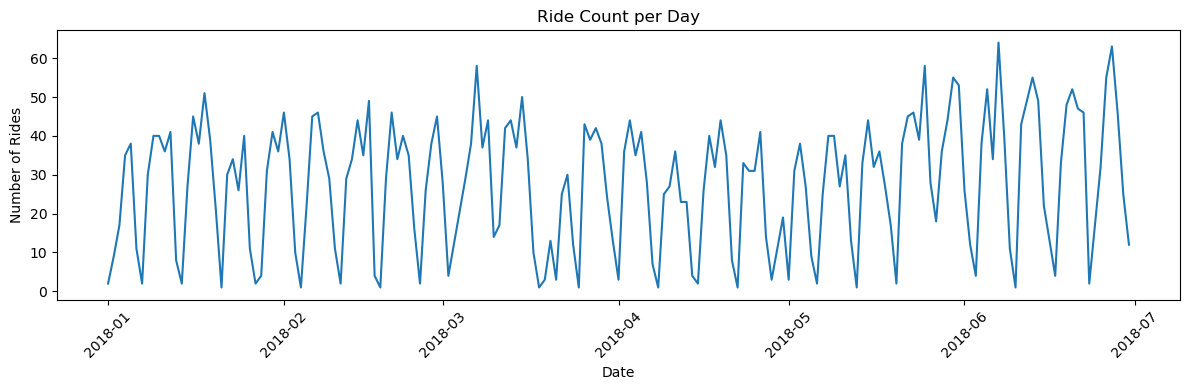

In [14]:
# --- EXPLORATORY DATA ANALYSIS ---

# 1. Number of rides per day
rides_per_day = df.groupby(df['booking_datetime'].dt.date).size()
plt.figure(figsize=(12, 4))
rides_per_day.plot()
plt.title("Ride Count per Day")
plt.ylabel("Number of Rides")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

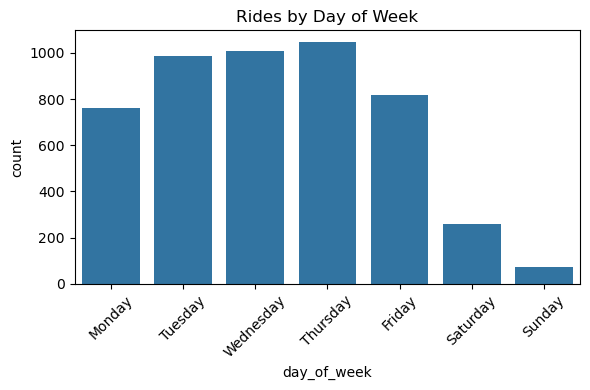

In [15]:
# 2. Rides by day of week
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='day_of_week', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title("Rides by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

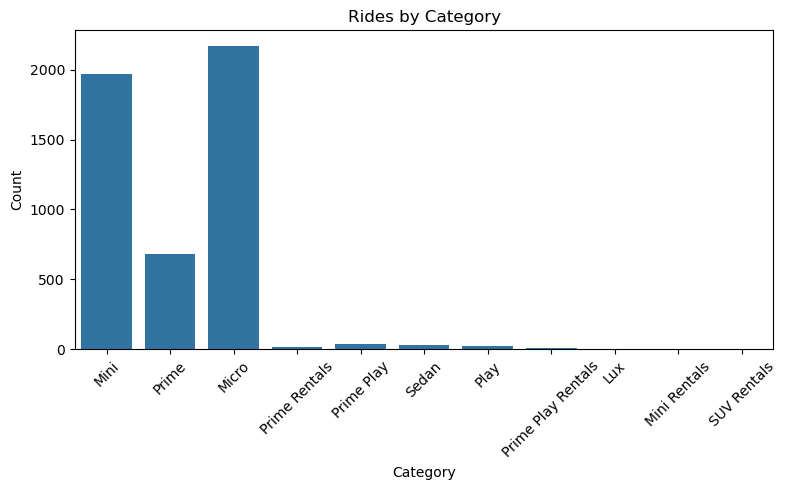

In [16]:
# 3. Ride count by category
plt.figure(figsize=(8, 5))
sns.countplot(x='category', data=df)
plt.title("Rides by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.show()

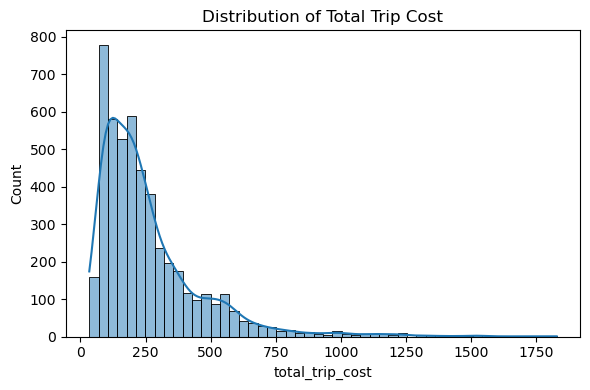

In [17]:
# 4. Trip cost distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['total_trip_cost'], bins=50, kde=True)
plt.title("Distribution of Total Trip Cost")
plt.tight_layout()
plt.show()

In [18]:
#SUMMARY
print("\nMissing values summary:\n", missing_summary)
print("\nBasic stats:\n", df[['distance_travelled', 'time_taken', 'total_trip_cost']].describe())


Missing values summary:
 booking id               0
booking_date_time        0
gender                   0
month                    0
day_of_week              0
time_of_day              0
distance_travelled       0
time_taken               0
reason                  93
toll                     0
category                 0
commission_base_cost     0
driver_base_cost         0
total_tax                0
total_trip_cost          0
ratings                  0
booking_datetime         0
dtype: int64

Basic stats:
        distance_travelled   time_taken  total_trip_cost
count         4950.000000  4950.000000      4950.000000
mean            11.713333    35.126137       262.074463
std             10.338660    25.592958       206.440318
min              0.000000     0.000000        34.000000
25%              4.000000     7.000000       122.000000
50%              8.500000    35.000000       203.000000
75%             16.000000    50.000000       324.750000
max             66.000000   192.000000 

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [20]:
# STEP 1: Aggregate the data to daily ride counts
df['date'] = df['booking_datetime'].dt.date
daily_demand = df.groupby('date').size().reset_index(name='ride_count')
daily_demand['booking_datetime'] = pd.to_datetime(daily_demand['date'])

In [21]:
# STEP 2: Feature engineering
daily_demand['day_of_week'] = daily_demand['booking_datetime'].dt.dayofweek
daily_demand['week_of_year'] = daily_demand['booking_datetime'].dt.isocalendar().week
daily_demand['month'] = daily_demand['booking_datetime'].dt.month
daily_demand['year'] = daily_demand['booking_datetime'].dt.year
daily_demand['is_weekend'] = daily_demand['day_of_week'].isin([5, 6]).astype(int)

In [22]:
# STEP 3: Prepare the features and target
features = ['day_of_week', 'week_of_year', 'month', 'year', 'is_weekend']
X = daily_demand[features]
y = daily_demand['ride_count']

In [23]:
# STEP 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [24]:
# STEP 5: Train XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
# STEP 6: Make predictions
y_pred = model.predict(X_test)

In [26]:
# STEP 7: Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 9.52
R² Score: 0.72


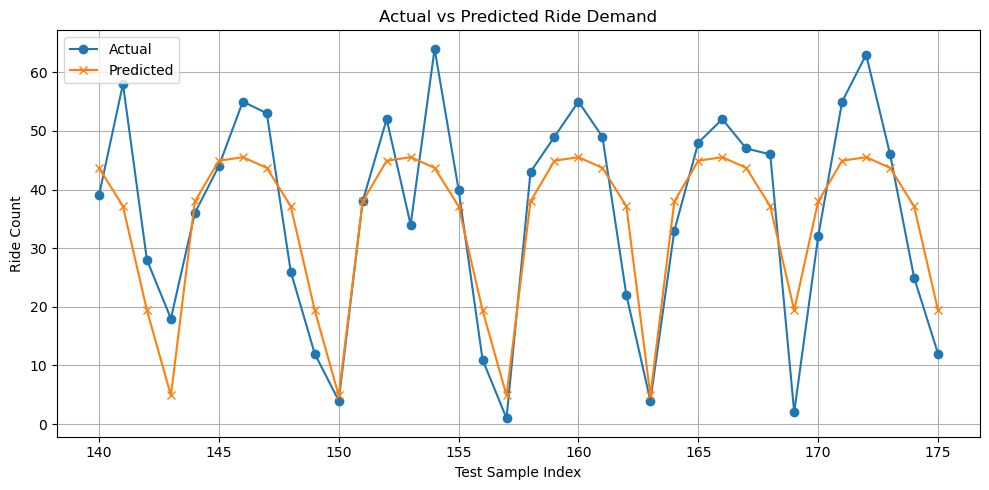

In [27]:
# STEP 8: Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', marker='x')
plt.title("Actual vs Predicted Ride Demand")
plt.xlabel("Test Sample Index")
plt.ylabel("Ride Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()